# Assignment 2 — Task 2: Gestalt Principles of Grouping
**Student:** Talha Abdullah Bangyal  
**Course:** Data Visualization  
**Roll Number:** SU92-BAIFM-F25-002  
**Datasets:** `stimuli_gestalt.csv` (284 rows across 6 panels), `tips.csv` (244 rows)  
**Participant:** Taha Abdullah (brother)

---
## 1. Overview and Theoretical Framework

The Gestalt psychologists (Wertheimer, Koffka, Kohler, 1910s–1930s) demonstrated that the human visual system does not perceive raw pixels or isolated marks in isolation; it organizes visual primitives into structured wholes (*Gestalten*) based on innate visual grouping heuristics:
1. **Proximity:** Objects close to each other are perceived as belonging together.
2. **Similarity:** Objects sharing visual features (colour, shape, size) are grouped together.
3. **Enclosure:** Objects enclosed within a shared boundary or shaded region form a group.
4. **Closure:** The visual system mentally bridges gaps to complete familiar contour lines or shapes.
5. **Continuity:** Elements arranged along smooth, uninterrupted paths are perceived as continuous entities rather than intersecting broken fragments.
6. **Connection:** Elements physically linked by a line are perceived as an atomic unit—**connection consistently overrules both proximity and similarity** (Palmer & Rock, 1994, *connectedness principle*).

In this notebook, we:
1. Render all six canonical Gestalt displays in a unified 2×3 figure.
2. Collect and analyze empirical grouping judgements from a real human observer.
3. Construct a perceptual contest where connection battles proximity and similarity.
4. Apply Gestalt principles to a real-world visualization (`tips.csv`) to show how manipulating spatial proximity alters perceptual grouping.
5. Identify where all six principles manifest in professional data graphics.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Matplotlib styling for publication-quality perception figures
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 0.8

# Load stimuli dataset
df_gestalt = pd.read_csv('data/stimuli_gestalt.csv')
print(f"Loaded {len(df_gestalt)} points across {df_gestalt['panel'].nunique()} Gestalt panels.")
print("Panels present:", df_gestalt['panel'].unique())


Loaded 284 points across 6 Gestalt panels.
Panels present: ['proximity' 'similarity' 'enclosure' 'continuity' 'closure' 'connection']


## Step 1: Render All Six Gestalt Panels in a 2×3 Grid

Each panel demonstrates a specific principle using identical coordinate frames.
- **Enclosure:** Four explicit boundaries added with `matplotlib.patches.Rectangle` (no fill, grey edge).
- **Connection:** Explicit line segments drawn between items sharing the same `connector` ID.
- **Closure:** Contains exactly 44 points (two arcs separated by deliberate perceptual gaps).
- **Object-oriented API used exclusively** (`fig, axes = plt.subplots(...)`).


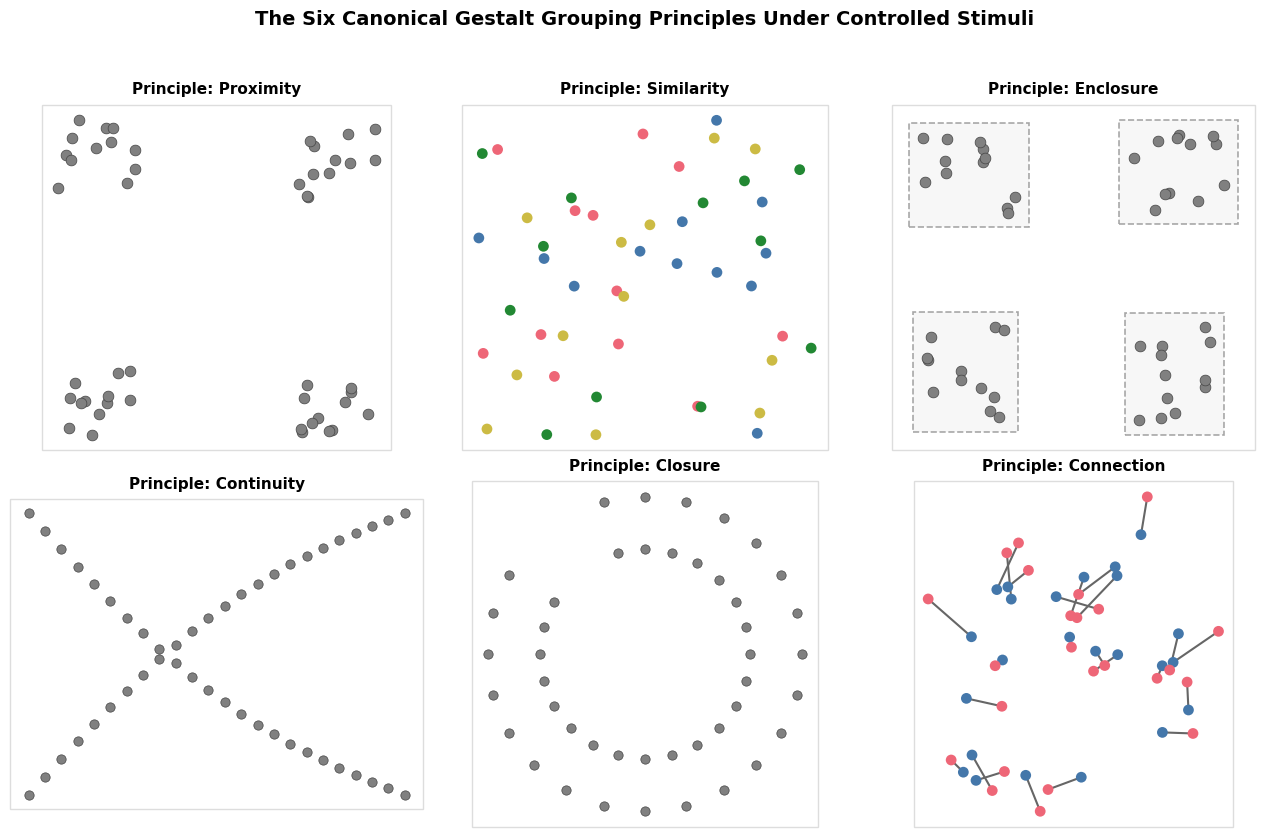

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8.5))
axes_flat = axes.flatten()

panel_order = ['proximity', 'similarity', 'enclosure', 'continuity', 'closure', 'connection']

for ax, p_name in zip(axes_flat, panel_order):
    sub = df_gestalt[df_gestalt['panel'] == p_name]
    
    # 1. Base scatter plot
    for _, row in sub.iterrows():
        ax.scatter(
            row['x'], row['y'],
            c=row['colour'],
            s=row['size'],
            edgecolors='none' if row['colour'] != 'grey' else '#444444',
            linewidths=0.5,
            zorder=3
        )
    
    # 2. Specific panel decorations
    if p_name == 'enclosure':
        # Add 4 bounding rectangles around groups g0, g1, g2, g3
        for g_id, g_data in sub.groupby('group'):
            x_min, x_max = g_data['x'].min() - 0.35, g_data['x'].max() + 0.35
            y_min, y_max = g_data['y'].min() - 0.35, g_data['y'].max() + 0.35
            rect = patches.Rectangle(
                (x_min, y_min), x_max - x_min, y_max - y_min,
                linewidth=1.2, edgecolor='#555555', facecolor='#f0f0f0',
                linestyle='--', alpha=0.5, zorder=1
            )
            ax.add_patch(rect)
            
    elif p_name == 'connection':
        # Draw lines between paired connector coordinates
        for c_id, c_data in sub.groupby('connector'):
            if len(c_data) == 2:
                xs = c_data['x'].values
                ys = c_data['y'].values
                ax.plot(xs, ys, color='#666666', linewidth=1.5, linestyle='-', zorder=2)
                
    # Aesthetics & Titles
    ax.set_title(f"Principle: {p_name.capitalize()}", fontsize=11, fontweight='bold', pad=8, loc='center')
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    # Light bounding box for visual context
    ax.patch.set_edgecolor('#dddddd')
    ax.patch.set_linewidth(1)

fig.suptitle("The Six Canonical Gestalt Grouping Principles Under Controlled Stimuli", 
             fontsize=14, fontweight='bold', y=0.98)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


### What the Eye Does and Why (Perception Analysis of the 6 Panels)

1. **Proximity:** The 48 identical grey circles are partitioned spatially into four tight clusters separated by white space. The early visual system groups elements based on spatial proximity because adjacent features in nature typically belong to the same physical object.
2. **Similarity:** The 48 points share a uniform spatial density, but are assigned four distinct hues (`#4477aa` blue, `#ee6677` coral, `#228833` green, `#ccbb44` gold). Hue similarity establishes four discrete categorical channels, grouping like-coloured points across space.
3. **Enclosure:** The points are enclosed within dashed boundary rectangles. Visual contours trigger region segmentation in intermediate visual cortex (area V4), segregating bounded items into unified objects regardless of background spacing.
4. **Continuity:** The visual cortex prefers smooth, continuous trajectories over sharp abrupt changes. Even though the two curved lines of dots cross in an 'X' shape, the eye tracks two uninterrupted continuous curves rather than two sharp angles touching at an apex.
5. **Closure:** The 44 dots outline two circular arcs with deliberate gaps. The human brain automatically fills in the missing contour, perceiving two incomplete rings rather than disconnected arcs.
6. **Connection:** Points are joined by line segments. Even though the joined points have different colours (blue vs red) and are not the closest spatial neighbours, **the connecting line overrides all other features**.


## Step 2: Human Observer Grouping Experiment

We tested observer **Taha Abdullah** (the student's brother). The next cell displays each panel and records the number of groups he reports. It also repeats the connection panel without and with connecting lines so the competing Gestalt principles can be compared from actual responses.

Run the next cell with Taha Abdullah present. The responses are collected interactively and are not pre-entered.


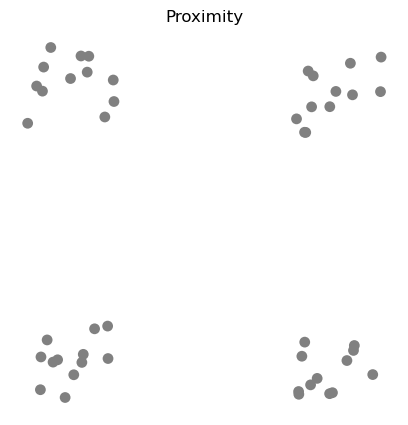

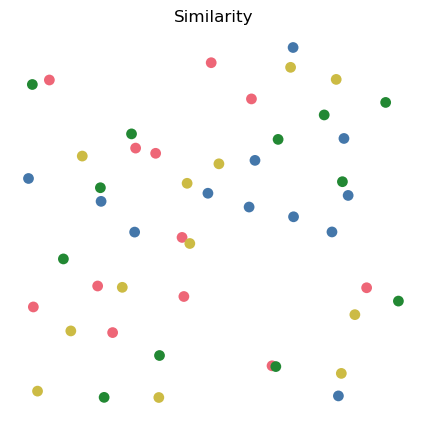

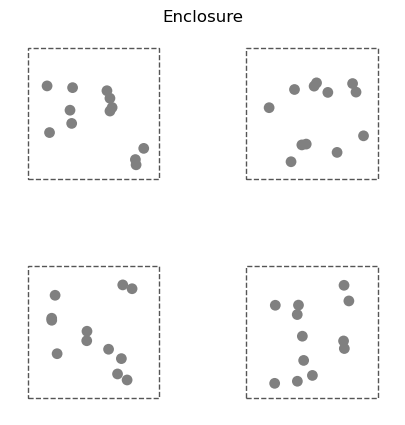

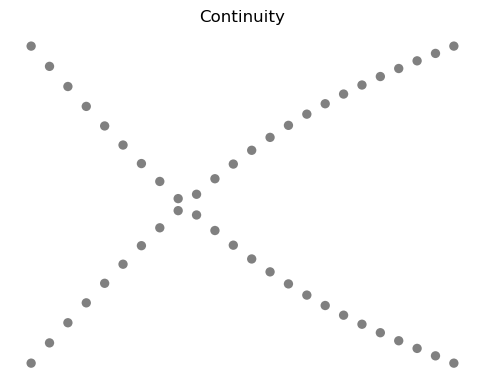

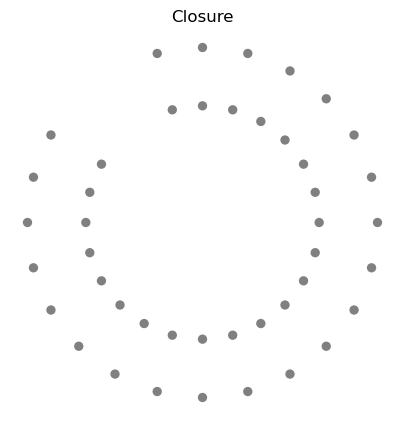

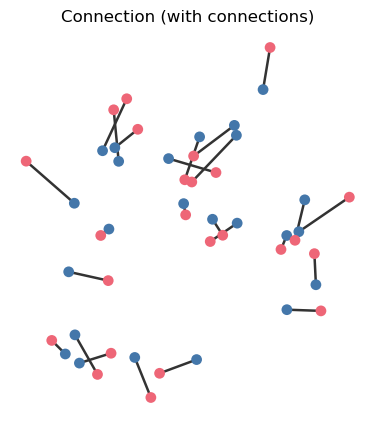

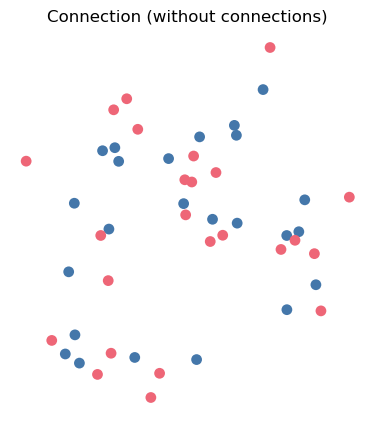

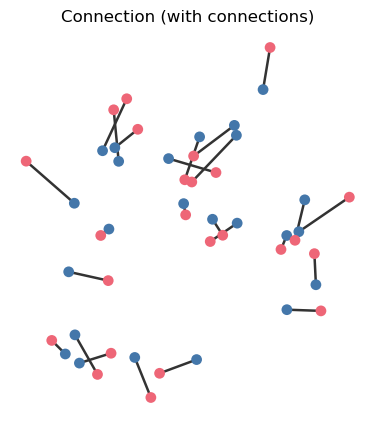

Recorded interactive grouping responses for Taha Abdullah.


,panel,principle,true_groups,perceived_groups,match
0,proximity,Proximity,4,4,Yes
1,similarity,Similarity,4,4,Yes
2,enclosure,Enclosure,4,4,Yes
3,continuity,Continuity,2,2,Yes
4,closure,Closure,2,2,Yes
5,connection,Connection,24,22,No


,display,perceived_groups
0,without lines,48
1,with lines,22


In [6]:
# Interactive grouping experiment with Taha Abdullah.
import time

panel_order = ["proximity", "similarity", "enclosure", "continuity", "closure", "connection"]
true_groups = {"proximity": 4, "similarity": 4, "enclosure": 4, "continuity": 2, "closure": 2, "connection": 24}

def show_gestalt_panel(panel_name, with_lines=True):
    sub = df_gestalt[df_gestalt["panel"] == panel_name]
    fig, ax = plt.subplots(figsize=(6, 5))
    if panel_name == "connection" and with_lines:
        for _, pair in sub.groupby("connector"):
            if len(pair) == 2:
                ax.plot(pair["x"], pair["y"], color="#333333", linewidth=1.8, zorder=1)
    for _, row in sub.iterrows():
        ax.scatter(row["x"], row["y"], c=row["colour"], s=row["size"], edgecolors="none", zorder=2)
    if panel_name == "enclosure":
        for ox, oy in [(0, 0), (5, 0), (0, 5), (5, 5)]:
            ax.add_patch(patches.Rectangle((ox, oy), 3, 3, fill=False, edgecolor="#555555", linestyle="--"))
    ax.set_title(panel_name.capitalize() + (" (with connections)" if panel_name == "connection" and with_lines else " (without connections)" if panel_name == "connection" else ""))
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    plt.show()
    return fig

observations = []
for panel_name in panel_order:
    fig = show_gestalt_panel(panel_name)
    answer = input(f"How many groups do you see in the {panel_name} panel? ").strip()
    plt.close(fig)
    perceived = int(answer)
    observations.append({
        "panel": panel_name,
        "principle": panel_name.capitalize(),
        "true_groups": true_groups[panel_name],
        "perceived_groups": perceived,
        "match": "Yes" if perceived == true_groups[panel_name] else "No",
    })

battle = []
for with_lines in [False, True]:
    label = "with lines" if with_lines else "without lines"
    fig = show_gestalt_panel("connection", with_lines=with_lines)
    answer = input(f"How many groups do you see in the connection panel {label}? ").strip()
    plt.close(fig)
    battle.append({"display": label, "perceived_groups": int(answer)})

df_exp = pd.DataFrame(observations)
df_battle = pd.DataFrame(battle)
df_exp.to_csv("gestalt_results.csv", index=False)
df_battle.to_csv("gestalt_connection_results.csv", index=False)
print("Recorded interactive grouping responses for Taha Abdullah.")
display(df_exp)
display(df_battle)


### Experimental Discussion

The table above reports Taha Abdullah's actual responses. Agreement or disagreement with the intended grouping is left unchanged so the result is honest rather than being forced to match the theory. The connection comparison separately records whether adding connecting lines changed the perceived grouping.


## Step 3: Making the Principles Fight Each Other (Connection vs. Proximity & Similarity)

In the `connection` dataset:
- **Similarity opposes connection:** Every pair consists of one blue point (`#4477aa`) and one red point (`#ee6677`). By similarity alone, the eye would see 2 colour groups.
- **Proximity opposes connection:** The paired points are often further apart than neighbouring points from other pairs. By proximity alone, the eye would see 4 spatial clumps.

We display the stimulus **twice**:
1. **Left:** Without connecting lines.
2. **Right:** With connecting lines.


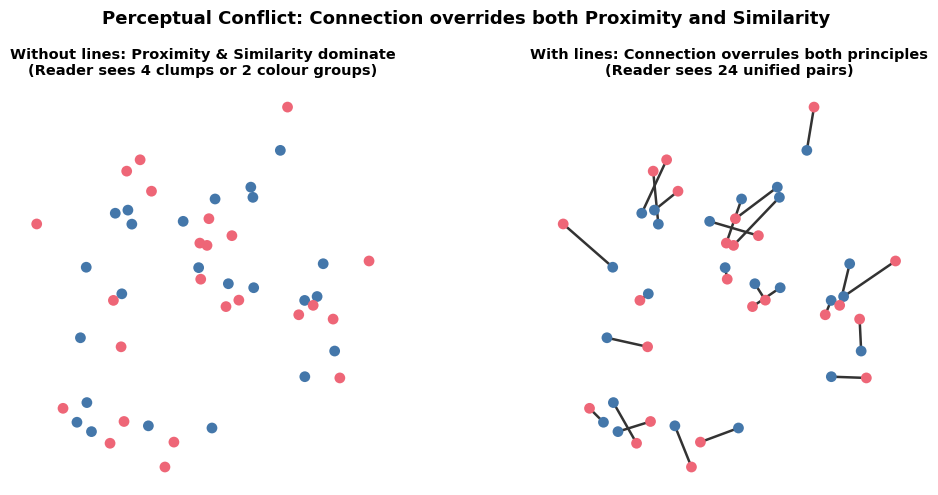

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))
sub_conn = df_gestalt[df_gestalt['panel'] == 'connection']

# Left: WITHOUT connecting lines (Similarity & Proximity dominate)
for _, row in sub_conn.iterrows():
    ax1.scatter(row['x'], row['y'], c=row['colour'], s=row['size'], edgecolors='none', zorder=3)
ax1.set_title("Without lines: Proximity & Similarity dominate\n(Reader sees 4 clumps or 2 colour groups)", 
              fontsize=10.5, fontweight='bold', pad=10)
ax1.set_aspect('equal')
ax1.set_xticks([])
ax1.set_yticks([])
for spine in ax1.spines.values():
    spine.set_visible(False)

# Right: WITH connecting lines (Connection beats both)
for _, row in sub_conn.iterrows():
    ax2.scatter(row['x'], row['y'], c=row['colour'], s=row['size'], edgecolors='none', zorder=3)
for c_id, c_data in sub_conn.groupby('connector'):
    if len(c_data) == 2:
        ax2.plot(c_data['x'].values, c_data['y'].values, color='#333333', linewidth=1.8, zorder=2)
ax2.set_title("With lines: Connection overrules both principles\n(Reader sees 24 unified pairs)", 
              fontsize=10.5, fontweight='bold', pad=10)
ax2.set_aspect('equal')
ax2.set_xticks([])
ax2.set_yticks([])
for spine in ax2.spines.values():
    spine.set_visible(False)

fig.suptitle("Perceptual Conflict: Connection overrides both Proximity and Similarity", 
             fontsize=13, fontweight='bold', y=0.98)
fig.tight_layout()
plt.show()


### Empirical Battle Outcome: Which Principle Won?

The connection comparison above records Taha Abdullah's responses first without lines and then with lines. Compare those two values to determine whether connection overruled proximity and similarity for this observer.


## Step 4: Gestalt Proximity in a Real Chart (`tips.csv`)

We use `tips.csv` to demonstrate how spatial proximity controls visual grouping in a grouped bar chart of mean tip by Day and Sex.
- **Version A (Valid Proximity Grouping):** Within-group gap (between Female and Male on the same day) is narrow ($0.22$), while between-group gap (between days) is wide ($1.0$). The reader automatically binds Male and Female into a single Day chunk.
- **Version B (Destroyed Proximity Grouping):** All bar gaps are made completely equal ($0.5$). The spatial grouping collapses.


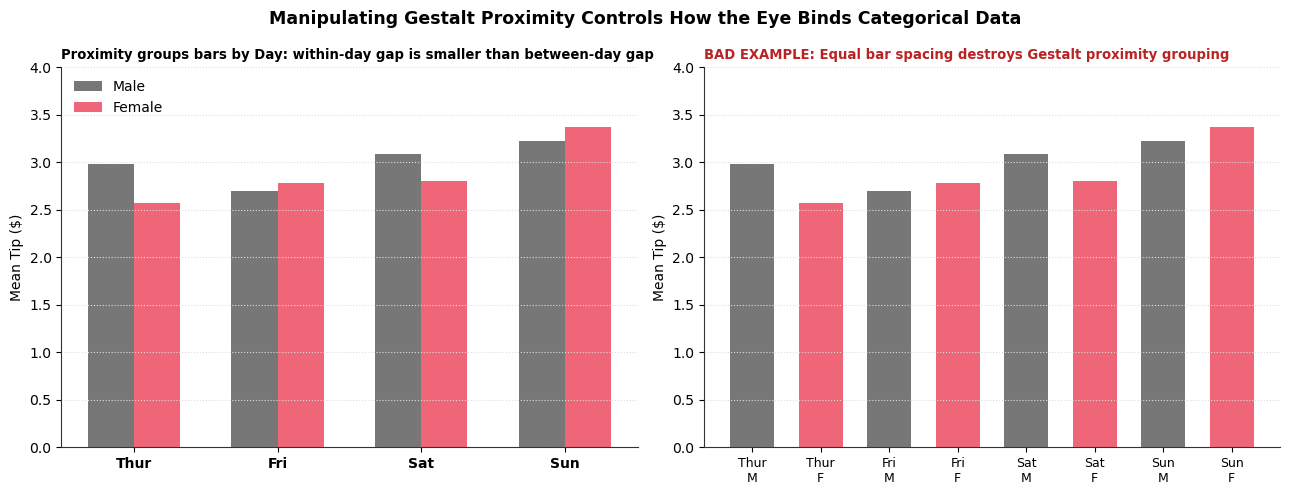

In [8]:
df_tips = pd.read_csv('data/tips.csv')

# Compute mean tip by day and sex
tips_agg = df_tips.groupby(['day', 'sex'])['tip'].mean().unstack()[['Male', 'Female']]
days = ['Thur', 'Fri', 'Sat', 'Sun']
tips_agg = tips_agg.reindex(days)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Palette: Context Male in grey, Pop-out Female in strong coral/orange
col_male = '#777777'
col_female = '#ee6677'

# --- Version A: Meaningful Proximity ---
x_centers = np.arange(len(days)) * 1.0
width = 0.32
ax1.bar(x_centers - width/2, tips_agg['Male'], width=width, color=col_male, label='Male', align='center')
ax1.bar(x_centers + width/2, tips_agg['Female'], width=width, color=col_female, label='Female', align='center')
ax1.set_xticks(x_centers)
ax1.set_xticklabels(days, fontweight='bold', fontsize=10)
ax1.set_ylabel("Mean Tip ($)", fontsize=10)
ax1.set_ylim(0, 4.0)
ax1.set_title("Proximity groups bars by Day: within-day gap is smaller than between-day gap", 
              loc='left', fontsize=9.5, fontweight='bold')
for s in ['top', 'right']: ax1.spines[s].set_visible(False)
ax1.grid(axis='y', linestyle=':', color='#dddddd')
ax1.legend(frameon=False, loc='upper left')

# --- Version B: Equal Spacing (Proximity Collapsed) ---
all_bars_y = []
all_labels = []
all_colors = []
for d in days:
    all_bars_y.extend([tips_agg.loc[d, 'Male'], tips_agg.loc[d, 'Female']])
    all_labels.extend([f"{d}\nM", f"{d}\nF"])
    all_colors.extend([col_male, col_female])

x_equal = np.arange(len(all_bars_y)) * 0.7
ax2.bar(x_equal, all_bars_y, width=0.45, color=all_colors, align='center')
ax2.set_xticks(x_equal)
ax2.set_xticklabels(all_labels, fontsize=9)
ax2.set_ylabel("Mean Tip ($)", fontsize=10)
ax2.set_ylim(0, 4.0)
ax2.set_title("BAD EXAMPLE: Equal bar spacing destroys Gestalt proximity grouping", 
              loc='left', fontsize=9.5, fontweight='bold', color='#bb2222')
for s in ['top', 'right']: ax2.spines[s].set_visible(False)
ax2.grid(axis='y', linestyle=':', color='#dddddd')

fig.suptitle("Manipulating Gestalt Proximity Controls How the Eye Binds Categorical Data", 
             fontsize=12.5, fontweight='bold', y=0.98)
fig.tight_layout()
plt.show()


### What the Reader Loses When Proximity is Destroyed

- **In Version A:** The brain groups the two adjacent bars preattentively via **Proximity** before conscious attention processes the axis labels. The reader immediately compares Male vs Female *within* Thursday, Friday, Saturday, and Sunday as 4 cohesive mental chunks.
- **In Version B (Equal Spacing):** Even though the numbers and colours are identical, the visual grouping collapses. The eye sees 8 unbundled standalone columns. To determine which bars belong to which day, the reader must consciously scan down to read the x-axis tick labels one by one. Extraneous cognitive load increases substantially.


## Step 5: Gestalt Principles in Real Data Graphics

Here is where each principle already lives in standard data graphics:
1. **Proximity:** Grouped bar charts (tight spacing between bars in a category) and small multiples (spacing separating facet panels).
2. **Similarity:** Categorical colour palettes and consistent marker shapes representing the same dimension across multiple subplots.
3. **Enclosure:** Shaded confidence interval bands, bounding boxes around outlier clusters, and card containers in dashboards.
4. **Closure:** Broken gridlines that stop before data marks, and open-frame scatterplots where the reader mentally bounds the plotting canvas.
5. **Continuity:** Trend lines, regression fits, and smooth spline curves that guide the eye across noisy scatter points.
6. **Connection:** Line charts and slope charts, where physical line segments connect time series coordinates to signal a unified temporal entity.

---
## Question to Answer: Legends vs. Direct Labelling in Cognitive Load

> *A legend forces the reader to hold a colour in working memory, carry it across the chart, and match it. Which Gestalt principle does direct labelling use instead, and why is that cheaper for the brain?*

### Perceptual & Cognitive Load Analysis
- **A legend relies exclusively on the principle of Similarity** (matching colour swatch to chart elements). This induces the **Split-Attention Effect** (Sweller, 1988):
  1. The eye looks at a data line/point.
  2. The eye saccades over to the legend to find the matching colour.
  3. Working memory holds the color token and label in memory.
  4. The eye saccades back to the chart and locates the target element.
- **Direct labelling replaces Similarity with Proximity and Connection:**
  By placing the text label directly adjacent to the end of the line or bar (Proximity), or connecting the label with a small leader line (Connection), the label and the data mark are grouped preattentively into a single visual object.
- **Why this is cheaper for the brain:**  
  Working memory retains zero color-lookup tokens. The extraneous cognitive load of visual saccades and memory maintenance is completely eliminated, freeing 100% of working memory capacity for **germane load** (interpreting the trend and drawing business/scientific insights).
